In [1]:
# ==========================
# Import Required Libraries
# ==========================

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

import warnings
warnings.filterwarnings("ignore")

print("All libraries imported successfully!")

All libraries imported successfully!


In [3]:
application = pd.read_csv("application_record.csv")
credit = pd.read_csv("credit_record.csv")

print("Application Dataset Shape:", application.shape)
print("Credit Dataset Shape:", credit.shape)

Application Dataset Shape: (143973, 18)
Credit Dataset Shape: (1048575, 3)


In [4]:
application.head()

,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,DAYS_BIRTH,DAYS_EMPLOYED,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS
0,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005.0,-4542.0,1.0,1.0,0.0,0.0,NaN,2.0
1,5008805,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005.0,-4542.0,1.0,1.0,0.0,0.0,NaN,2.0
2,5008806,M,Y,Y,0,112500.0,Working,Secondary / secondary special,Married,House / apartment,-21474.0,-1134.0,1.0,0.0,0.0,0.0,Security staff,2.0
3,5008808,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110.0,-3051.0,1.0,0.0,1.0,1.0,Sales staff,1.0
4,5008809,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110.0,-3051.0,1.0,0.0,1.0,1.0,Sales staff,1.0


In [5]:
credit.head()

,ID,MONTHS_BALANCE,STATUS
0,5001711,0,X
1,5001711,-1,0
2,5001711,-2,0
3,5001711,-3,0
4,5001712,0,C


In [6]:
print("Application Dataset Information")
application.info()

print("\nCredit Dataset Information")
credit.info()

Application Dataset Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 143973 entries, 0 to 143972
Data columns (total 18 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   ID                   143973 non-null  int64  
 1   CODE_GENDER          143973 non-null  object 
 2   FLAG_OWN_CAR         143973 non-null  object 
 3   FLAG_OWN_REALTY      143973 non-null  object 
 4   CNT_CHILDREN         143973 non-null  int64  
 5   AMT_INCOME_TOTAL     143973 non-null  float64
 6   NAME_INCOME_TYPE     143973 non-null  object 
 7   NAME_EDUCATION_TYPE  143973 non-null  object 
 8   NAME_FAMILY_STATUS   143972 non-null  object 
 9   NAME_HOUSING_TYPE    143972 non-null  object 
 10  DAYS_BIRTH           143972 non-null  float64
 11  DAYS_EMPLOYED        143972 non-null  float64
 12  FLAG_MOBIL           143972 non-null  float64
 13  FLAG_WORK_PHONE      143972 non-null  float64
 14  FLAG_PHONE           143972 non-null

In [7]:
print("Application Missing Values")
print(application.isnull().sum())

print("\nCredit Missing Values")
print(credit.isnull().sum())

Application Missing Values
ID                         0
CODE_GENDER                0
FLAG_OWN_CAR               0
FLAG_OWN_REALTY            0
CNT_CHILDREN               0
AMT_INCOME_TOTAL           0
NAME_INCOME_TYPE           0
NAME_EDUCATION_TYPE        0
NAME_FAMILY_STATUS         1
NAME_HOUSING_TYPE          1
DAYS_BIRTH                 1
DAYS_EMPLOYED              1
FLAG_MOBIL                 1
FLAG_WORK_PHONE            1
FLAG_PHONE                 1
FLAG_EMAIL                 1
OCCUPATION_TYPE        44811
CNT_FAM_MEMBERS            1
dtype: int64

Credit Missing Values
ID                0
MONTHS_BALANCE    0
STATUS            0
dtype: int64


In [8]:
print("Application Duplicates :", application.duplicated().sum())
print("Credit Duplicates :", credit.duplicated().sum())

Application Duplicates : 0
Credit Duplicates : 0


In [9]:
application['OCCUPATION_TYPE'] = application['OCCUPATION_TYPE'].fillna('Unknown')

# Check again
application.isnull().sum()

,0
ID,0
CODE_GENDER,0
FLAG_OWN_CAR,0
FLAG_OWN_REALTY,0
CNT_CHILDREN,0
AMT_INCOME_TOTAL,0
NAME_INCOME_TYPE,0
NAME_EDUCATION_TYPE,0
NAME_FAMILY_STATUS,1
NAME_HOUSING_TYPE,1


In [10]:
application.drop_duplicates(inplace=True)
credit.drop_duplicates(inplace=True)

print("Application Shape:", application.shape)
print("Credit Shape:", credit.shape)

Application Shape: (143973, 18)
Credit Shape: (1048575, 3)


In [11]:
application.columns

Index(['ID', 'CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'CNT_CHILDREN',
       'AMT_INCOME_TOTAL', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE',
       'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'DAYS_BIRTH',
       'DAYS_EMPLOYED', 'FLAG_MOBIL', 'FLAG_WORK_PHONE', 'FLAG_PHONE',
       'FLAG_EMAIL', 'OCCUPATION_TYPE', 'CNT_FAM_MEMBERS'],
      dtype='object')

In [12]:
credit.head()

,ID,MONTHS_BALANCE,STATUS
0,5001711,0,X
1,5001711,-1,0
2,5001711,-2,0
3,5001711,-3,0
4,5001712,0,C


In [13]:
credit.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1048575 entries, 0 to 1048574
Data columns (total 3 columns):
 #   Column          Non-Null Count    Dtype 
---  ------          --------------    ----- 
 0   ID              1048575 non-null  int64 
 1   MONTHS_BALANCE  1048575 non-null  int64 
 2   STATUS          1048575 non-null  object
dtypes: int64(2), object(1)
memory usage: 24.0+ MB


In [14]:
credit.isnull().sum()

,0
ID,0
MONTHS_BALANCE,0
STATUS,0


In [16]:


credit['TARGET'] = credit['STATUS'].apply(
    lambda x: 1 if x in ['1','2','3','4','5'] else 0
)

credit.head()

,ID,MONTHS_BALANCE,STATUS,TARGET
0,5001711,0,X,0
1,5001711,-1,0,0
2,5001711,-2,0,0
3,5001711,-3,0,0
4,5001712,0,C,0


In [17]:
credit_target = credit.groupby('ID')['TARGET'].max().reset_index()

credit_target.head()

,ID,TARGET
0,5001711,0
1,5001712,0
2,5001713,0
3,5001714,0
4,5001715,0


In [18]:
data = application.merge(credit_target, on='ID', how='inner')

data.head()

,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,DAYS_BIRTH,DAYS_EMPLOYED,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,TARGET
0,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005.0,-4542.0,1.0,1.0,0.0,0.0,Unknown,2.0,1
1,5008805,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005.0,-4542.0,1.0,1.0,0.0,0.0,Unknown,2.0,1
2,5008806,M,Y,Y,0,112500.0,Working,Secondary / secondary special,Married,House / apartment,-21474.0,-1134.0,1.0,0.0,0.0,0.0,Security staff,2.0,0
3,5008808,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110.0,-3051.0,1.0,0.0,1.0,1.0,Sales staff,1.0,0
4,5008809,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110.0,-3051.0,1.0,0.0,1.0,1.0,Sales staff,1.0,0


In [19]:
print(data.shape)
data.info()

(36105, 19)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36105 entries, 0 to 36104
Data columns (total 19 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   36105 non-null  int64  
 1   CODE_GENDER          36105 non-null  object 
 2   FLAG_OWN_CAR         36105 non-null  object 
 3   FLAG_OWN_REALTY      36105 non-null  object 
 4   CNT_CHILDREN         36105 non-null  int64  
 5   AMT_INCOME_TOTAL     36105 non-null  float64
 6   NAME_INCOME_TYPE     36105 non-null  object 
 7   NAME_EDUCATION_TYPE  36105 non-null  object 
 8   NAME_FAMILY_STATUS   36105 non-null  object 
 9   NAME_HOUSING_TYPE    36105 non-null  object 
 10  DAYS_BIRTH           36105 non-null  float64
 11  DAYS_EMPLOYED        36105 non-null  float64
 12  FLAG_MOBIL           36105 non-null  float64
 13  FLAG_WORK_PHONE      36105 non-null  float64
 14  FLAG_PHONE           36105 non-null  float64
 15  FLAG_EMAIL           361

In [20]:
data['TARGET'].value_counts()

,count
TARGET,
0,32166
1,3939


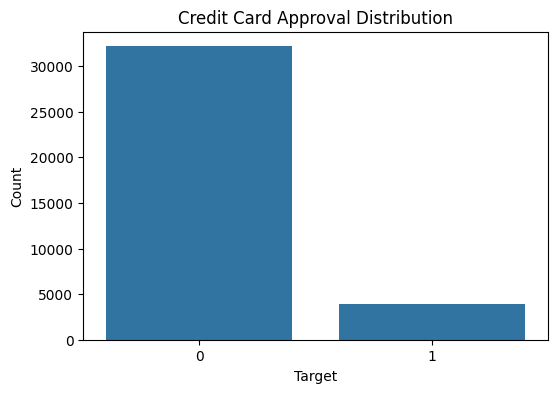

In [21]:
plt.figure(figsize=(6,4))

sns.countplot(x='TARGET', data=data)

plt.title("Credit Card Approval Distribution")
plt.xlabel("Target")
plt.ylabel("Count")

plt.show()

In [22]:
data.head()

,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,DAYS_BIRTH,DAYS_EMPLOYED,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,TARGET
0,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005.0,-4542.0,1.0,1.0,0.0,0.0,Unknown,2.0,1
1,5008805,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005.0,-4542.0,1.0,1.0,0.0,0.0,Unknown,2.0,1
2,5008806,M,Y,Y,0,112500.0,Working,Secondary / secondary special,Married,House / apartment,-21474.0,-1134.0,1.0,0.0,0.0,0.0,Security staff,2.0,0
3,5008808,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110.0,-3051.0,1.0,0.0,1.0,1.0,Sales staff,1.0,0
4,5008809,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110.0,-3051.0,1.0,0.0,1.0,1.0,Sales staff,1.0,0


In [23]:
print("Rows and Columns:", data.shape)

Rows and Columns: (36105, 19)


In [24]:
data.describe()

,ID,CNT_CHILDREN,AMT_INCOME_TOTAL,DAYS_BIRTH,DAYS_EMPLOYED,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,CNT_FAM_MEMBERS,TARGET
count,3.610500e+04,36105.000000,3.610500e+04,36105.000000,36105.000000,36105.0,36105.000000,36105.000000,36105.000000,36105.000000,36105.000000
mean,5.078205e+06,0.430854,1.866752e+05,-15976.549453,59190.176818,1.0,0.225592,0.295278,0.089766,2.199501,0.109098
std,4.186918e+04,0.742747,1.018650e+05,4200.196605,137591.973094,0.0,0.417977,0.456174,0.285850,0.911920,0.311767
min,5.008804e+06,0.000000,2.700000e+04,-25152.000000,-15713.000000,1.0,0.000000,0.000000,0.000000,1.000000,0.000000
25%,5.042019e+06,0.000000,1.215000e+05,-19439.000000,-3153.000000,1.0,0.000000,0.000000,0.000000,2.000000,0.000000
50%,5.074548e+06,0.000000,1.575000e+05,-15564.000000,-1555.000000,1.0,0.000000,0.000000,0.000000,2.000000,0.000000
75%,5.114649e+06,1.000000,2.250000e+05,-12475.000000,-410.000000,1.0,0.000000,1.000000,0.000000,3.000000,0.000000
max,5.150487e+06,19.000000,1.575000e+06,-7489.000000,365243.000000,1.0,1.000000,1.000000,1.000000,20.000000,1.000000


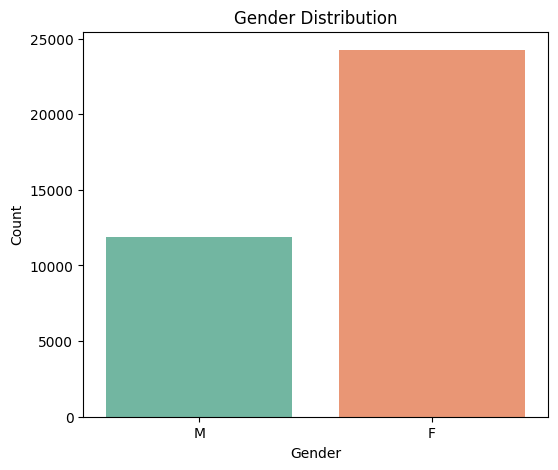

In [25]:
plt.figure(figsize=(6,5))
sns.countplot(x='CODE_GENDER', data=data, palette='Set2')
plt.title("Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Count")
plt.show()

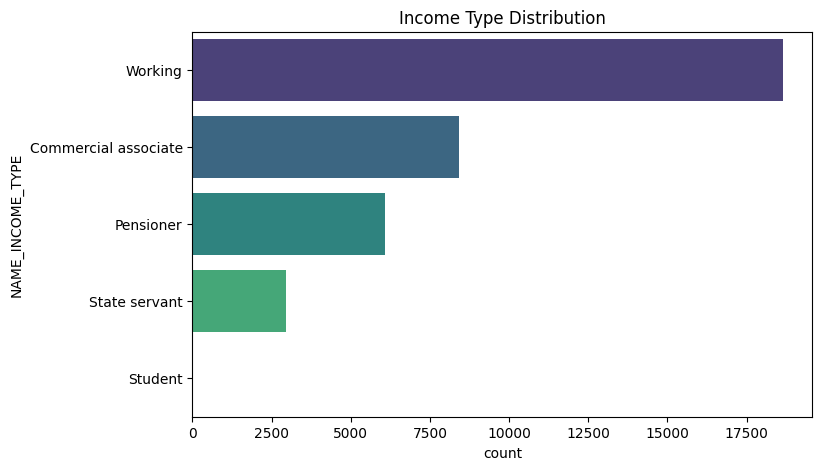

In [26]:
plt.figure(figsize=(8,5))
sns.countplot(y='NAME_INCOME_TYPE', data=data, palette='viridis')
plt.title("Income Type Distribution")
plt.show()

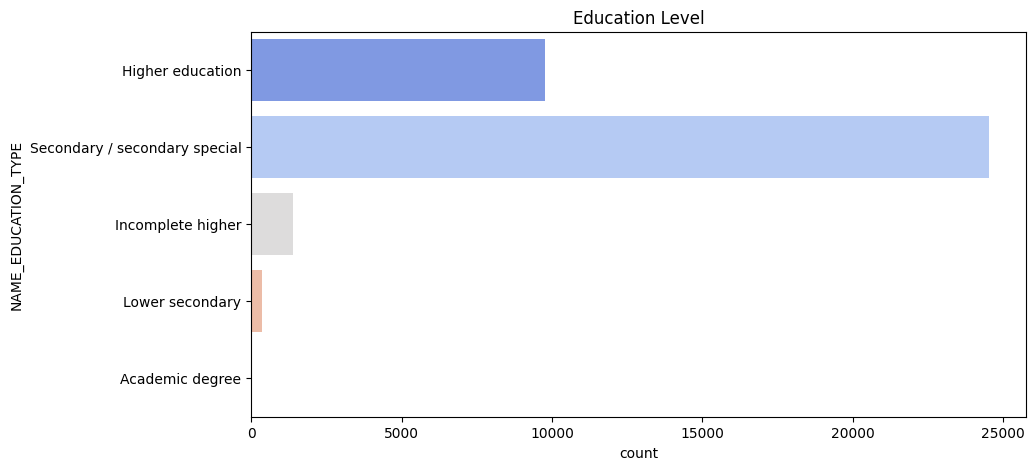

In [27]:
plt.figure(figsize=(10,5))
sns.countplot(y='NAME_EDUCATION_TYPE', data=data, palette='coolwarm')
plt.title("Education Level")
plt.show()

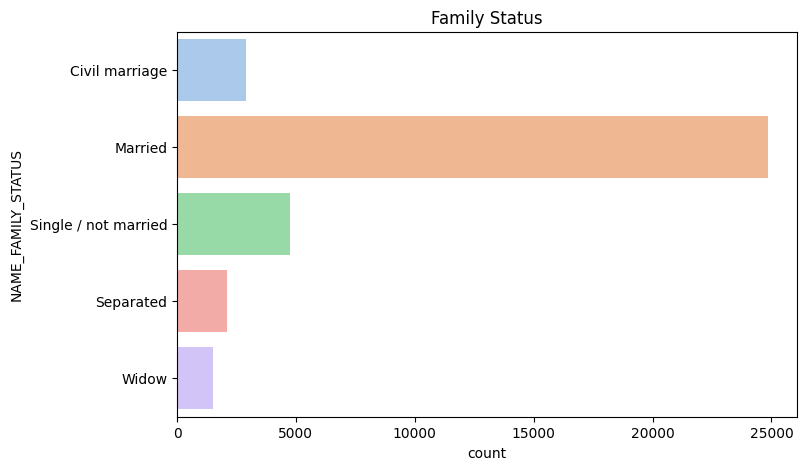

In [28]:
plt.figure(figsize=(8,5))
sns.countplot(y='NAME_FAMILY_STATUS', data=data, palette='pastel')
plt.title("Family Status")
plt.show()

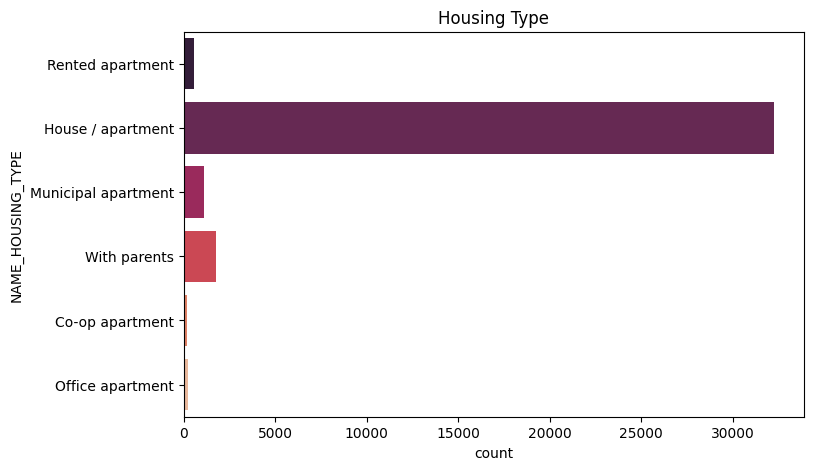

In [29]:
plt.figure(figsize=(8,5))
sns.countplot(y='NAME_HOUSING_TYPE', data=data, palette='rocket')
plt.title("Housing Type")
plt.show()

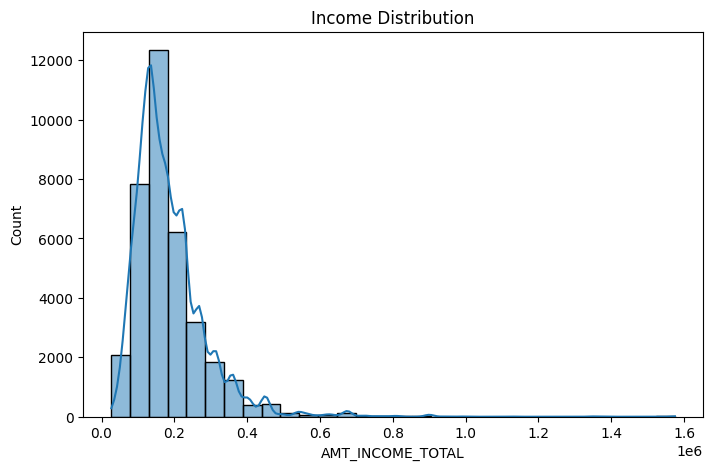

In [30]:
plt.figure(figsize=(8,5))
sns.histplot(data['AMT_INCOME_TOTAL'], bins=30, kde=True)
plt.title("Income Distribution")
plt.show()

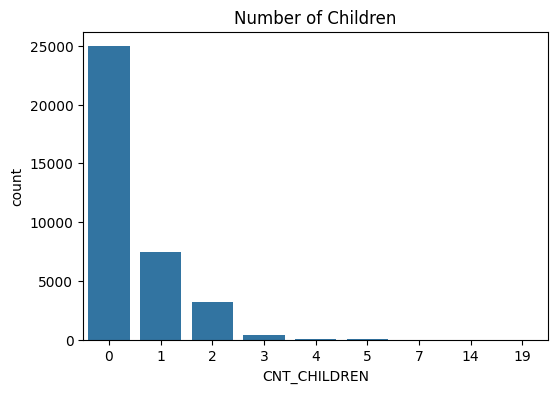

In [31]:
plt.figure(figsize=(6,4))
sns.countplot(x='CNT_CHILDREN', data=data)
plt.title("Number of Children")
plt.show()

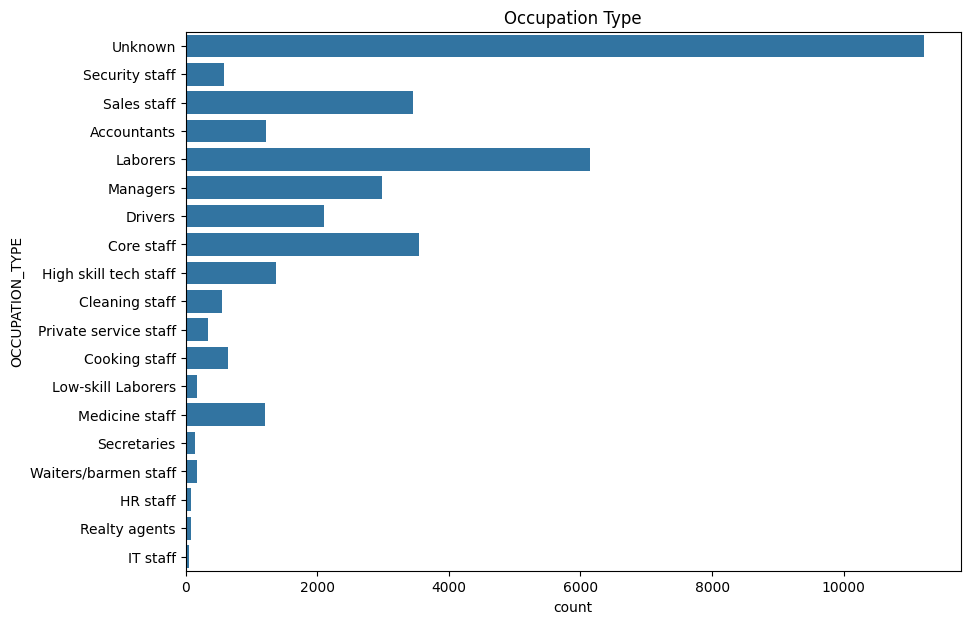

In [32]:
plt.figure(figsize=(10,7))
sns.countplot(y='OCCUPATION_TYPE', data=data)
plt.title("Occupation Type")
plt.show()

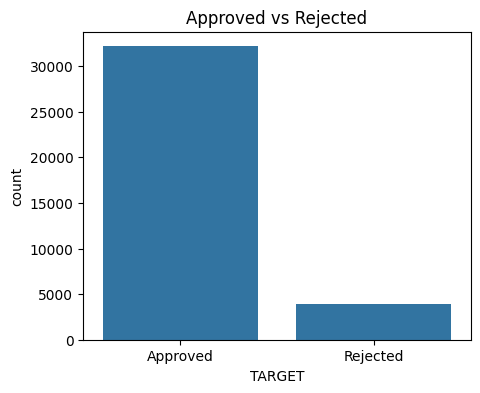

In [33]:
plt.figure(figsize=(5,4))
sns.countplot(x='TARGET', data=data)
plt.title("Approved vs Rejected")
plt.xticks([0,1],['Approved','Rejected'])
plt.show()

In [35]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

data_encoded = data.copy()

for col in data_encoded.columns:
    if data_encoded[col].dtype == 'object':
        data_encoded[col] = le.fit_transform(data_encoded[col].astype(str))

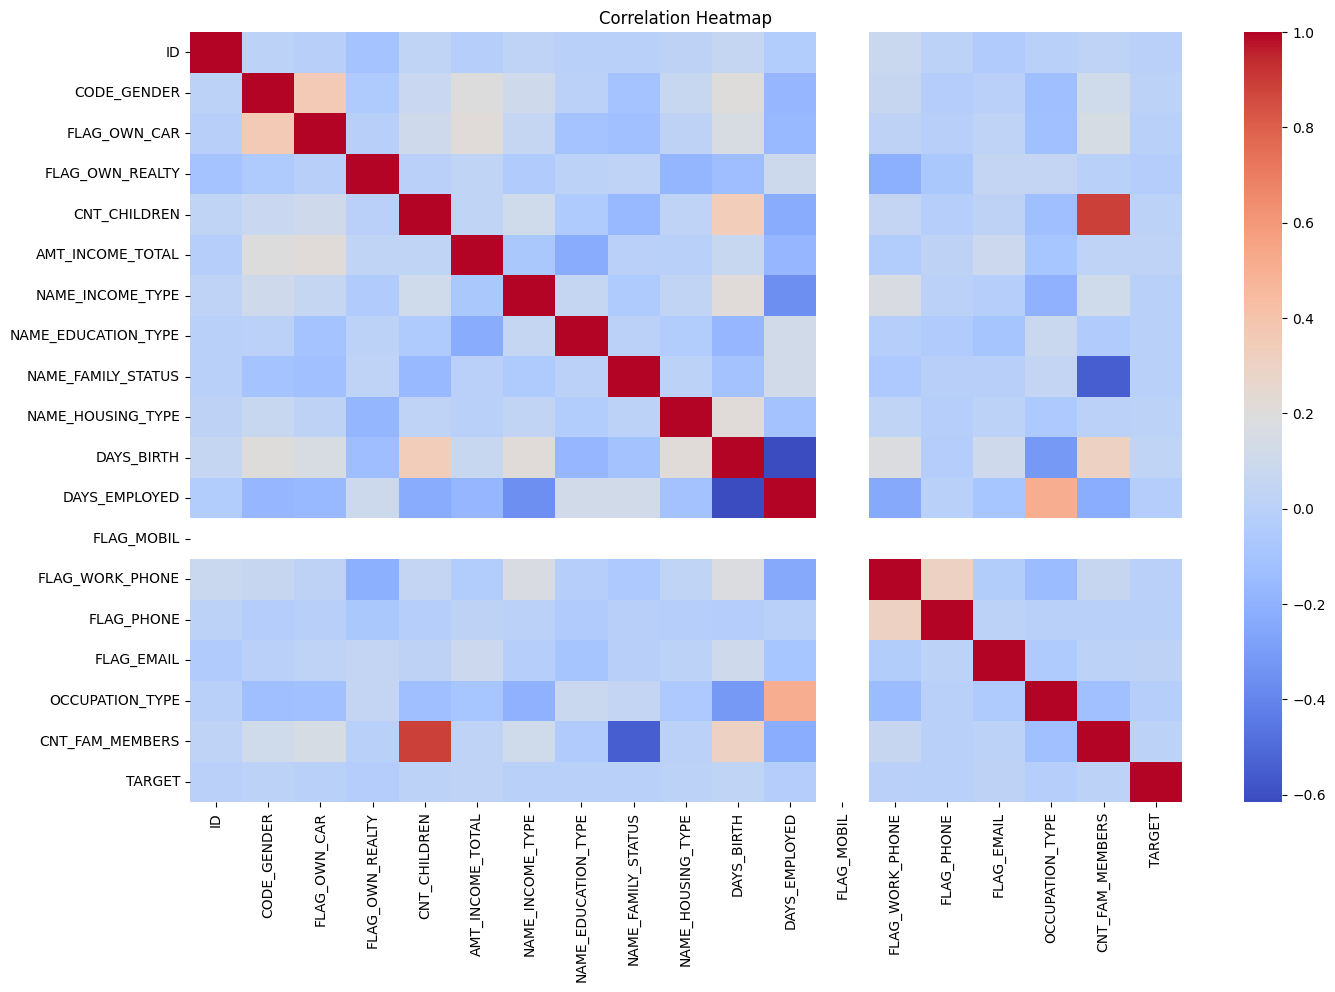

In [36]:
plt.figure(figsize=(16,10))
sns.heatmap(data_encoded.corr(), cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

In [37]:
X = data_encoded.drop(['ID', 'TARGET'], axis=1)
y = data_encoded['TARGET']

print("Features Shape:", X.shape)
print("Target Shape:", y.shape)

Features Shape: (36105, 17)
Target Shape: (36105,)


In [38]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(28884, 17)
(7221, 17)


In [39]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000)

lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

print("Logistic Regression Accuracy:", accuracy_score(y_test, lr_pred))

Logistic Regression Accuracy: 0.8872732308544523


In [40]:
print(classification_report(y_test, lr_pred))

              precision    recall  f1-score   support

           0       0.89      1.00      0.94      6407
           1       0.00      0.00      0.00       814

    accuracy                           0.89      7221
   macro avg       0.44      0.50      0.47      7221
weighted avg       0.79      0.89      0.83      7221



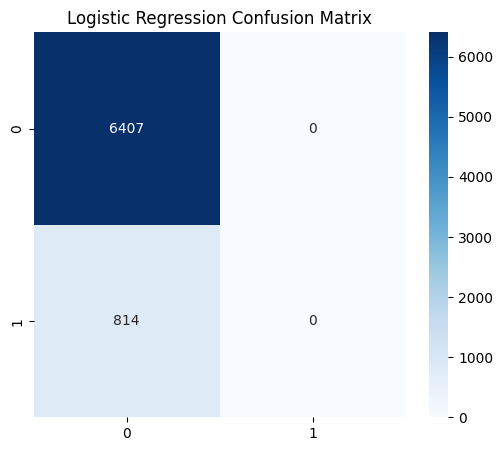

In [41]:
plt.figure(figsize=(6,5))
sns.heatmap(confusion_matrix(y_test, lr_pred),
            annot=True,
            fmt='d',
            cmap='Blues')

plt.title("Logistic Regression Confusion Matrix")
plt.show()

In [42]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(random_state=42)

dt.fit(X_train, y_train)

dt_pred = dt.predict(X_test)

print("Decision Tree Accuracy:", accuracy_score(y_test, dt_pred))

Decision Tree Accuracy: 0.8827032266999031


In [43]:
print(classification_report(y_test, dt_pred))

              precision    recall  f1-score   support

           0       0.91      0.96      0.94      6407
           1       0.47      0.30      0.36       814

    accuracy                           0.88      7221
   macro avg       0.69      0.63      0.65      7221
weighted avg       0.86      0.88      0.87      7221



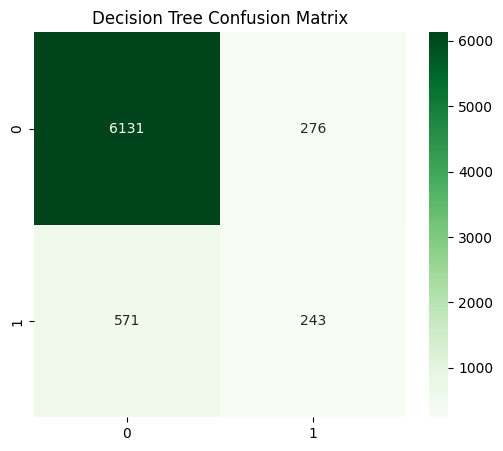

In [44]:
plt.figure(figsize=(6,5))
sns.heatmap(confusion_matrix(y_test, dt_pred),
            annot=True,
            fmt='d',
            cmap='Greens')

plt.title("Decision Tree Confusion Matrix")
plt.show()

In [45]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, rf_pred))

Random Forest Accuracy: 0.8893505054701565


In [46]:
print(classification_report(y_test, rf_pred))

              precision    recall  f1-score   support

           0       0.92      0.96      0.94      6407
           1       0.52      0.30      0.38       814

    accuracy                           0.89      7221
   macro avg       0.72      0.63      0.66      7221
weighted avg       0.87      0.89      0.88      7221



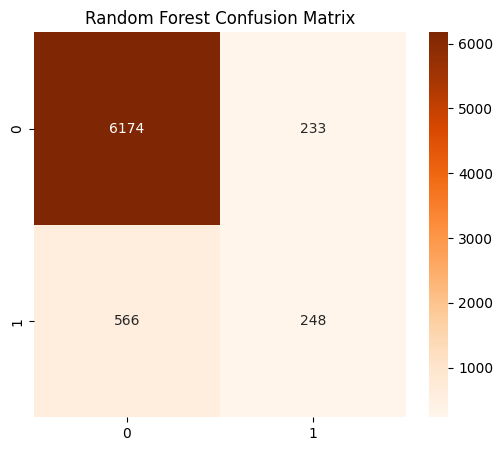

In [47]:
plt.figure(figsize=(6,5))
sns.heatmap(confusion_matrix(y_test, rf_pred),
            annot=True,
            fmt='d',
            cmap='Oranges')

plt.title("Random Forest Confusion Matrix")
plt.show()

In [48]:
!pip install xgboost

In [49]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    random_state=42,
    eval_metric='logloss'
)

xgb.fit(X_train, y_train)

xgb_pred = xgb.predict(X_test)

print("XGBoost Accuracy:", accuracy_score(y_test, xgb_pred))

XGBoost Accuracy: 0.8907353552139593


In [50]:
print(classification_report(y_test, xgb_pred))

              precision    recall  f1-score   support

           0       0.90      0.99      0.94      6407
           1       0.58      0.11      0.19       814

    accuracy                           0.89      7221
   macro avg       0.74      0.55      0.56      7221
weighted avg       0.86      0.89      0.86      7221



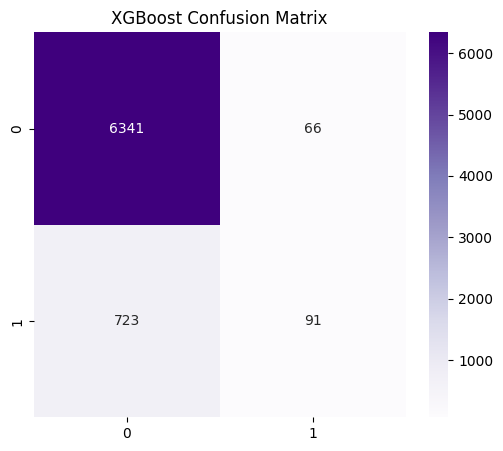

In [51]:
plt.figure(figsize=(6,5))
sns.heatmap(confusion_matrix(y_test, xgb_pred),
            annot=True,
            fmt='d',
            cmap='Purples')

plt.title("XGBoost Confusion Matrix")
plt.show()

In [52]:
results = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'Decision Tree',
        'Random Forest',
        'XGBoost'
    ],
    'Accuracy': [
        accuracy_score(y_test, lr_pred),
        accuracy_score(y_test, dt_pred),
        accuracy_score(y_test, rf_pred),
        accuracy_score(y_test, xgb_pred)
    ]
})

results.sort_values(by='Accuracy', ascending=False)

,Model,Accuracy
3,XGBoost,0.890735
2,Random Forest,0.889351
0,Logistic Regression,0.887273
1,Decision Tree,0.882703


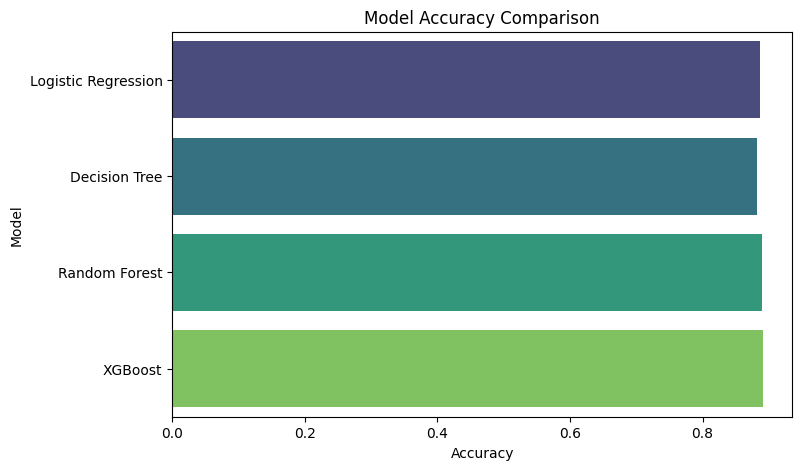

In [53]:
plt.figure(figsize=(8,5))

sns.barplot(
    x='Accuracy',
    y='Model',
    data=results,
    palette='viridis'
)

plt.title("Model Accuracy Comparison")
plt.show()

In [54]:
import pickle

pickle.dump(rf, open("best_model.pkl", "wb"))

print("Model Saved Successfully!")

Model Saved Successfully!
